# SPI Data Explorer
**ADB AI for Safer Roads Innovation Challenge 2026**

This notebook explores `Road_Safety_Performance_Indicators_(Helmet_Wearing_results)_(adb_dashboard_data_v02).xlsx`:
- Sheet and file structure
- Column definitions and analytical importance
- Unique values per categorical column
- Statistical summary of SPI values
- Pivot tables: SPI by Location × LandUse and Location × User Type
- Year-on-year trend analysis
- 5 charts: by location, by user type, urban vs rural, trend, driver vs passenger heatmap

All outputs saved to `results/SPIData/`.

## 0. Setup — Install Dependencies & Imports

In [1]:
!pip install pandas numpy matplotlib seaborn openpyxl

In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display

# --- Paths ---
SCRIPT_DIR  = os.path.dirname(os.path.abspath('__file__'))
BASE_DIR    = os.path.dirname(os.path.dirname(SCRIPT_DIR))   # ADB Challenge 2026T4
DATA_FILE   = os.path.join(BASE_DIR, 'Data', 'Archive',
              'Road_Safety_Performance_Indicators_(Helmet_Wearing_results)_(adb_dashboard_data_v02).xlsx')
RESULTS_DIR = os.path.join(BASE_DIR, 'results', 'SPIData')
os.makedirs(RESULTS_DIR, exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')

print(f'Data file  : {DATA_FILE}')
print(f'Results dir: {RESULTS_DIR}')

Data file  : C:\Users\amoli\OneDrive\ADB Challenge 2026T3\Data\Archive\Road_Safety_Performance_Indicators_(Helmet_Wearing_results)_(adb_dashboard_data_v02).xlsx
Results dir: C:\Users\amoli\OneDrive\ADB Challenge 2026T3\results\SPIData


## 1. File & Sheet Overview

In [3]:
xl = pd.ExcelFile(DATA_FILE)
df = xl.parse(xl.sheet_names[0])

print(f'Sheet names  : {xl.sheet_names}')
print(f'Active sheet : {xl.sheet_names[0]}')
print(f'Rows         : {len(df)}')
print(f'Columns      : {list(df.columns)}')
print()
display(df)

Sheet names  : ['Data For Dashboard_0']
Active sheet : Data For Dashboard_0
Rows         : 32
Columns      : ['Location', 'LandUse', 'User', 'Year', 'SPI', 'FID']



,Location,LandUse,User,Year,SPI,FID
0,Thailand,Combined,All Riders,All,0.778,1
1,Thailand,Combined,Driver,All,0.790,2
2,Thailand,Combined,Passenger,All,0.705,3
3,Thailand,Urban,All Riders,All,0.789,4
4,Thailand,Urban,Driver,All,0.800,5
5,Thailand,Urban,Passenger,All,0.719,6
6,Thailand,Rural,All Riders,All,0.672,7
7,Thailand,Rural,Driver,All,0.689,8
8,Thailand,Rural,Passenger,All,0.562,9
9,Thailand,Combined,All Riders,2021,0.759,10


## 2. Column Overview
Data types, completeness, unique value counts and sample values for each column.

In [4]:
overview = []
for col in df.columns:
    non_null = int(df[col].notna().sum())
    overview.append({
        'Column':        col,
        'DType':         str(df[col].dtype),
        'Non-Null':      non_null,
        '% Filled':      round(100 * non_null / len(df), 1),
        'Unique Values': df[col].nunique(),
        'Sample Value':  str(df[col].dropna().iloc[0]) if non_null > 0 else 'N/A',
    })

df_overview = pd.DataFrame(overview)
df_overview.to_csv(os.path.join(RESULTS_DIR, 'column_overview.csv'), index=False)
print('Saved: column_overview.csv\n')
display(df_overview)

Saved: column_overview.csv



,Column,DType,Non-Null,% Filled,Unique Values,Sample Value
0,Location,str,32,100.0,4,Thailand
1,LandUse,str,32,100.0,3,Combined
2,User,str,32,100.0,3,All Riders
3,Year,str,32,100.0,6,All
4,SPI,float64,32,100.0,31,0.778
5,FID,int64,32,100.0,32,1


## 3. Column Definitions & Analytical Importance

In [5]:
COLUMN_META = {
    'Location': {
        'definition': 'Geographic area the SPI value applies to: Thailand (national), Maharashtra (state), Mumbai (city), or Pune (city).',
        'importance': 'HIGH — primary grouping variable; enables comparison of helmet wearing rates across countries and cities.'
    },
    'LandUse': {
        'definition': 'Land use classification: Combined (urban + rural together), Urban, or Rural.',
        'importance': 'HIGH — rural and urban areas have very different helmet wearing rates; always stratify by this when comparing.'
    },
    'User': {
        'definition': 'Rider type: All Riders (aggregate), Driver (motorcycle driver), or Passenger (pillion passenger).',
        'importance': 'HIGH — passenger compliance is typically far lower than driver compliance; disaggregating reveals hidden risk.'
    },
    'Year': {
        'definition': "Year of observation, or 'All' for the multi-year aggregate SPI.",
        'importance': 'HIGH — year-over-year trends show whether helmet wearing is improving or declining.'
    },
    'SPI': {
        'definition': 'Safety Performance Indicator — proportion of riders observed wearing a helmet (0.0 = none, 1.0 = all). Measured via roadside surveys.',
        'importance': 'HIGH — the core metric of this dataset; directly measures helmet compliance as a road safety outcome.'
    },
    'FID': {
        'definition': 'Feature ID — unique integer row identifier assigned by the database system.',
        'importance': 'LOW — internal record identifier; not used in analysis.'
    },
}

meta_rows = []
for col in df.columns:
    m = COLUMN_META.get(col, {'definition': 'No definition available.', 'importance': 'UNKNOWN'})
    meta_rows.append({'Column': col, 'Definition': m['definition'], 'Importance': m['importance']})

df_meta = pd.DataFrame(meta_rows)
df_meta.to_csv(os.path.join(RESULTS_DIR, 'column_definitions.csv'), index=False)
print('Saved: column_definitions.csv\n')
pd.set_option('display.max_colwidth', 120)
display(df_meta)

Saved: column_definitions.csv



,Column,Definition,Importance
0,Location,"Geographic area the SPI value applies to: Thailand (national), Maharashtra (state), Mumbai (city), or Pune (city).",HIGH — primary grouping variable; enables comparison of helmet wearing rates across countries and cities.
1,LandUse,"Land use classification: Combined (urban + rural together), Urban, or Rural.",HIGH — rural and urban areas have very different helmet wearing rates; always stratify by this when comparing.
2,User,"Rider type: All Riders (aggregate), Driver (motorcycle driver), or Passenger (pillion passenger).",HIGH — passenger compliance is typically far lower than driver compliance; disaggregating reveals hidden risk.
3,Year,"Year of observation, or 'All' for the multi-year aggregate SPI.",HIGH — year-over-year trends show whether helmet wearing is improving or declining.
4,SPI,"Safety Performance Indicator — proportion of riders observed wearing a helmet (0.0 = none, 1.0 = all). Measured via ...",HIGH — the core metric of this dataset; directly measures helmet compliance as a road safety outcome.
5,FID,Feature ID — unique integer row identifier assigned by the database system.,LOW — internal record identifier; not used in analysis.


## 4. Unique Values Per Categorical Column

In [6]:
for col in ['Location', 'LandUse', 'User', 'Year']:
    vals = sorted(df[col].dropna().unique().tolist(), key=str)
    print(f'{col} ({len(vals)} unique values): {vals}')
    display(df[col].value_counts().rename('Count').to_frame())
    print()

Location (4 unique values): ['Maharashtra', 'Mumbai', 'Pune', 'Thailand']


,Count
Location,
Thailand,13
Maharashtra,13
Mumbai,3
Pune,3



LandUse (3 unique values): ['Combined', 'Rural', 'Urban']


,Count
LandUse,
Combined,20
Urban,6
Rural,6



User (3 unique values): ['All Riders', 'Driver', 'Passenger']


,Count
User,
All Riders,16
Driver,8
Passenger,8



Year (6 unique values): ['2021', '2022', '2023', '2024', '2025', 'All']


,Count
Year,
All,24
2022,2
2023,2
2024,2
2021,1
2025,1


## 5. SPI Statistical Summary

In [7]:
display(df['SPI'].describe().round(4).to_frame())

df.to_csv(os.path.join(RESULTS_DIR, 'spi_full_data.csv'), index=False)
print('Saved: spi_full_data.csv')

,SPI
count,32.0000
mean,0.4264
std,0.2998
min,0.0060
25%,0.1975
50%,0.3030
75%,0.7290
max,0.8060


Saved: spi_full_data.csv


## 6. Pivot: SPI by Location × LandUse
Filter: All Riders, All years — shows the aggregate helmet rate for each location broken down by land use.

In [8]:
pivot_loc_lu = df[
    (df['User'] == 'All Riders') & (df['Year'] == 'All')
].pivot_table(index='Location', columns='LandUse', values='SPI').round(3)

pivot_loc_lu.to_csv(os.path.join(RESULTS_DIR, 'pivot_location_landuse.csv'))
print('Saved: pivot_location_landuse.csv\n')
display(pivot_loc_lu.style.format('{:.3f}').background_gradient(cmap='RdYlGn', vmin=0, vmax=1))

Saved: pivot_location_landuse.csv



LandUse,Combined,Rural,Urban
Location,,,
Maharashtra,0.209,0.148,0.237
Mumbai,0.555,nan,nan
Pune,0.213,nan,nan
Thailand,0.778,0.672,0.789


## 7. Pivot: SPI by Location × User Type
Filter: Combined land use, All years — reveals the gap between driver and passenger compliance.

In [9]:
pivot_loc_user = df[
    (df['LandUse'] == 'Combined') & (df['Year'] == 'All')
].pivot_table(index='Location', columns='User', values='SPI').round(3)

pivot_loc_user.to_csv(os.path.join(RESULTS_DIR, 'pivot_location_user.csv'))
print('Saved: pivot_location_user.csv\n')
display(pivot_loc_user.style.format('{:.3f}').background_gradient(cmap='RdYlGn', vmin=0, vmax=1))

Saved: pivot_location_user.csv



User,All Riders,Driver,Passenger
Location,,,
Maharashtra,0.209,0.267,0.012
Mumbai,0.555,0.680,0.006
Pune,0.213,0.265,0.011
Thailand,0.778,0.790,0.705


## 8. Year-on-Year Trend
Filter: All Riders, Combined land use — only locations that have year-specific data.

In [10]:
trend = df[
    (df['User'] == 'All Riders') &
    (df['LandUse'] == 'Combined') &
    (df['Year'] != 'All')
].copy()
trend['Year'] = trend['Year'].astype(int)

trend.to_csv(os.path.join(RESULTS_DIR, 'year_trend.csv'), index=False)
print('Saved: year_trend.csv\n')
display(trend[['Location', 'Year', 'SPI']].sort_values(['Location', 'Year']).reset_index(drop=True))

Saved: year_trend.csv



,Location,Year,SPI
0,Maharashtra,2022,0.308
1,Maharashtra,2023,0.198
2,Maharashtra,2024,0.202
3,Maharashtra,2025,0.183
4,Thailand,2021,0.759
5,Thailand,2022,0.806
6,Thailand,2023,0.769
7,Thailand,2024,0.789


## 9. Charts

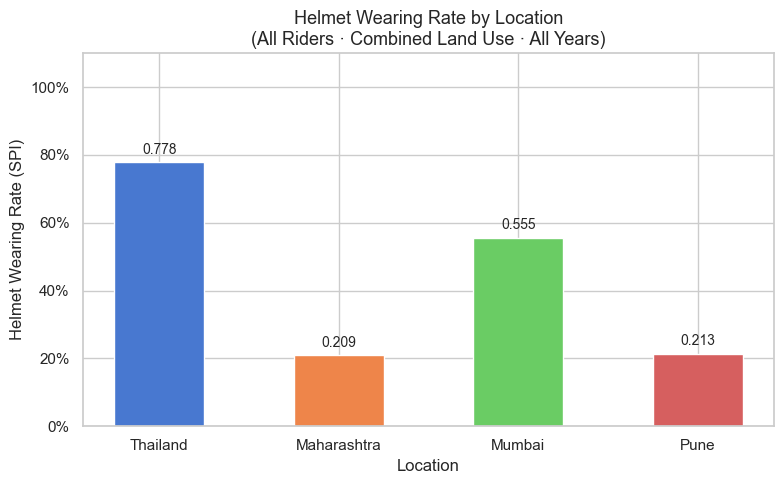

Saved: chart1_spi_by_location.png


In [11]:
# Chart 1: SPI by Location (All Riders, Combined, All years)
agg = df[(df['User'] == 'All Riders') & (df['LandUse'] == 'Combined') & (df['Year'] == 'All')]
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(agg['Location'], agg['SPI'],
              color=sns.color_palette('muted', len(agg)), edgecolor='white', width=0.5)
ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=10)
ax.set_ylim(0, 1.1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('Helmet Wearing Rate by Location\n(All Riders · Combined Land Use · All Years)', fontsize=13)
ax.set_xlabel('Location')
ax.set_ylabel('Helmet Wearing Rate (SPI)')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'chart1_spi_by_location.png'), dpi=150)
plt.show()
print('Saved: chart1_spi_by_location.png')

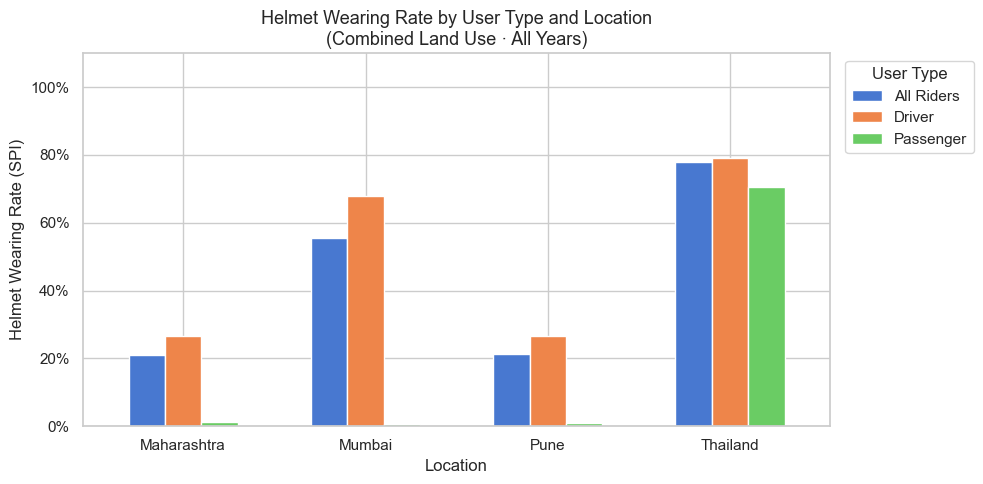

Saved: chart2_spi_by_user_location.png


In [12]:
# Chart 2: SPI by User Type per Location (Combined, All years)
user_data = df[(df['LandUse'] == 'Combined') & (df['Year'] == 'All')]
pivot2 = user_data.pivot_table(index='Location', columns='User', values='SPI')
fig, ax = plt.subplots(figsize=(10, 5))
pivot2.plot(kind='bar', ax=ax, width=0.6, edgecolor='white')
ax.set_ylim(0, 1.1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('Helmet Wearing Rate by User Type and Location\n(Combined Land Use · All Years)', fontsize=13)
ax.set_xlabel('Location')
ax.set_ylabel('Helmet Wearing Rate (SPI)')
ax.legend(title='User Type', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'chart2_spi_by_user_location.png'), dpi=150)
plt.show()
print('Saved: chart2_spi_by_user_location.png')

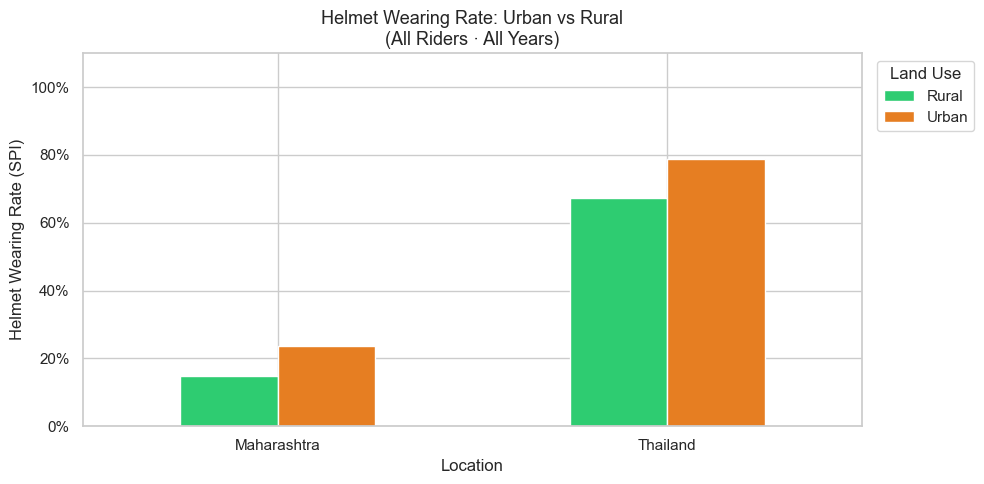

Saved: chart3_urban_vs_rural.png


In [13]:
# Chart 3: Urban vs Rural SPI per Location (All Riders, All years)
lu_data = df[(df['User'] == 'All Riders') & (df['Year'] == 'All') & (df['LandUse'] != 'Combined')]
pivot3 = lu_data.pivot_table(index='Location', columns='LandUse', values='SPI')
fig, ax = plt.subplots(figsize=(10, 5))
pivot3.plot(kind='bar', ax=ax, width=0.5, edgecolor='white', color=['#2ecc71', '#e67e22'])
ax.set_ylim(0, 1.1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('Helmet Wearing Rate: Urban vs Rural\n(All Riders · All Years)', fontsize=13)
ax.set_xlabel('Location')
ax.set_ylabel('Helmet Wearing Rate (SPI)')
ax.legend(title='Land Use', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'chart3_urban_vs_rural.png'), dpi=150)
plt.show()
print('Saved: chart3_urban_vs_rural.png')

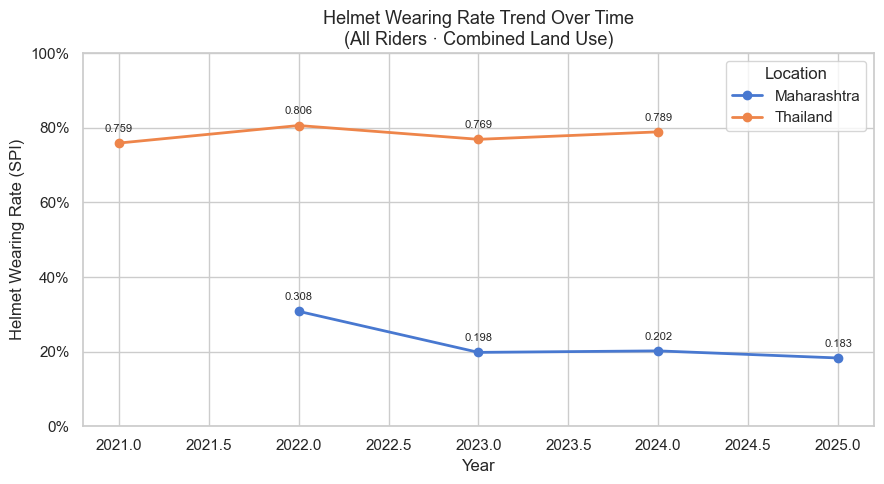

Saved: chart4_year_trend.png


In [14]:
# Chart 4: Year-on-year trend
fig, ax = plt.subplots(figsize=(9, 5))
for loc, grp in trend.groupby('Location'):
    ax.plot(grp['Year'], grp['SPI'], marker='o', linewidth=2, label=loc)
    for _, row in grp.iterrows():
        ax.annotate(f"{row['SPI']:.3f}", (row['Year'], row['SPI']),
                    textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)
ax.set_ylim(0, 1.0)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('Helmet Wearing Rate Trend Over Time\n(All Riders · Combined Land Use)', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Helmet Wearing Rate (SPI)')
ax.legend(title='Location')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'chart4_year_trend.png'), dpi=150)
plt.show()
print('Saved: chart4_year_trend.png')

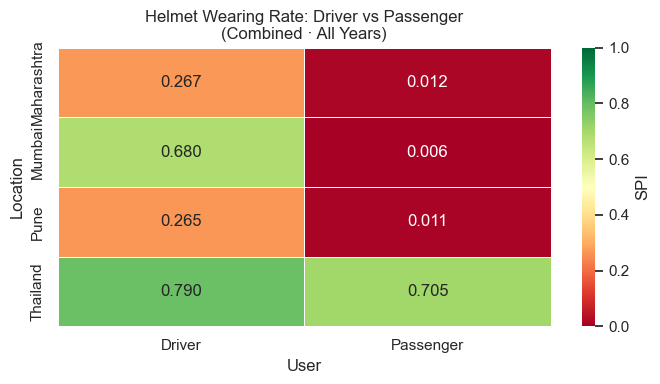

Saved: chart5_driver_vs_passenger_heatmap.png


In [15]:
# Chart 5: Driver vs Passenger heatmap
heat_data = df[
    (df['User'].isin(['Driver', 'Passenger'])) &
    (df['LandUse'] == 'Combined') &
    (df['Year'] == 'All')
].pivot_table(index='Location', columns='User', values='SPI').round(3)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(heat_data, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0, vmax=1, linewidths=0.5, ax=ax, cbar_kws={'label': 'SPI'})
ax.set_title('Helmet Wearing Rate: Driver vs Passenger\n(Combined · All Years)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'chart5_driver_vs_passenger_heatmap.png'), dpi=150)
plt.show()
print('Saved: chart5_driver_vs_passenger_heatmap.png')

## Done
All outputs saved to `results/SPIData/`:
- `column_overview.csv`
- `column_definitions.csv`
- `spi_full_data.csv`
- `pivot_location_landuse.csv`
- `pivot_location_user.csv`
- `year_trend.csv`
- `chart1_spi_by_location.png`
- `chart2_spi_by_user_location.png`
- `chart3_urban_vs_rural.png`
- `chart4_year_trend.png`
- `chart5_driver_vs_passenger_heatmap.png`